# 02 · Latent-class trajectory modeling (lcmm)

Fit a group-based latent-class linear mixed model of `NP1PAIN` over time (years), pick K by BIC, and crosstab class × DBS arm.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(lcmm); library(dplyr); library(ggplot2) })
df <- readRDS(file.path(OUT_OBJ, "pain_long.rds")) %>%
  dplyr::mutate(time_years = time_pos_months / 12) %>%
  dplyr::filter(!is.na(NP1PAIN), !is.na(time_years))
cat("Rows:", nrow(df), "  Patients:", dplyr::n_distinct(df$PATNO), "\n")

Rows: 6320   Patients: 170 


In [2]:
set.seed(42)
m1 <- lcmm::hlme(
  fixed = NP1PAIN ~ time_years, random = ~ time_years,
  subject = "PATNO", ng = 1, data = df)
cat("K=1 BIC:", round(m1$BIC, 2), "  conv:", m1$conv, "\n")

K=1 BIC: 14862.05   conv: 1 


In [3]:
fit_k <- function(k, tries = 6) {
  best <- NULL
  for (s in seq_len(tries)) {
    set.seed(42 + s)
    fit <- tryCatch(
      lcmm::hlme(
        fixed = NP1PAIN ~ time_years, mixture = ~ time_years,
        random = ~ time_years, subject = "PATNO",
        ng = k, data = df, B = lcmm::random(m1)),
      error = function(e) NULL)
    if (!is.null(fit) && isTRUE(fit$conv == 1)) {
      if (is.null(best) || fit$BIC < best$BIC) best <- fit
    }
  }
  best
}
m2 <- fit_k(2); m3 <- fit_k(3); m4 <- fit_k(4)
bic_tbl <- data.frame(
  K = 1:4,
  BIC = c(m1$BIC, if (!is.null(m2)) m2$BIC else NA,
          if (!is.null(m3)) m3$BIC else NA, if (!is.null(m4)) m4$BIC else NA),
  AIC = c(m1$AIC, if (!is.null(m2)) m2$AIC else NA,
          if (!is.null(m3)) m3$AIC else NA, if (!is.null(m4)) m4$AIC else NA),
  converged = c(m1$conv, if (!is.null(m2)) m2$conv else NA,
                if (!is.null(m3)) m3$conv else NA, if (!is.null(m4)) m4$conv else NA)
)
print(bic_tbl)
save_table(bic_tbl, "lcmm_model_selection")

  K      BIC      AIC converged
1 1 14862.05 14843.23         1
2 2       NA       NA        NA
3 3       NA       NA        NA
4 4       NA       NA        NA


In [4]:
fits <- list(`1` = m1, `2` = m2, `3` = m3, `4` = m4)
fits <- fits[!sapply(fits, is.null)]
conv_ok <- sapply(fits, function(x) isTRUE(x$conv == 1))
bics <- sapply(fits, function(x) x$BIC)
best_k <- names(bics)[which.min(ifelse(conv_ok, bics, Inf))]
cat("Best K by BIC (converged):", best_k, "\n")
best <- fits[[best_k]]

# For K=1 the pprob table may not be present; build membership accordingly
if (!is.null(best$pprob) && "class" %in% names(best$pprob)) {
  cls <- tibble::as_tibble(best$pprob) %>% dplyr::select(PATNO, class) %>% dplyr::distinct()
} else {
  cls <- df %>% dplyr::distinct(PATNO) %>% dplyr::mutate(class = 1L)
}
cat("\nClass sizes:\n"); print(dplyr::count(cls, class, name = "n_patients"))

Best K by BIC (converged): 1 



Class sizes:


# A tibble: 1 × 2
  class n_patients
  <int>      <int>
1     1        170


In [5]:
arm <- df %>% dplyr::distinct(PATNO, will_receive_dbs)
cls_arm <- cls %>% dplyr::inner_join(arm, by = "PATNO") %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
if (dplyr::n_distinct(cls_arm$class) > 1) {
  ctab <- table(cls_arm$class, cls_arm$arm)
  print(ctab); print(round(prop.table(ctab, margin = 2), 3))
  print(suppressWarnings(stats::chisq.test(ctab)))
  save_table(as.data.frame.matrix(ctab) %>% tibble::rownames_to_column("class"),
             "lcmm_class_by_arm")
} else {
  cat("Only one class identified (K=1 best) — no class×arm crosstab.\n")
}

Only one class identified (K=1 best) — no class×arm crosstab.


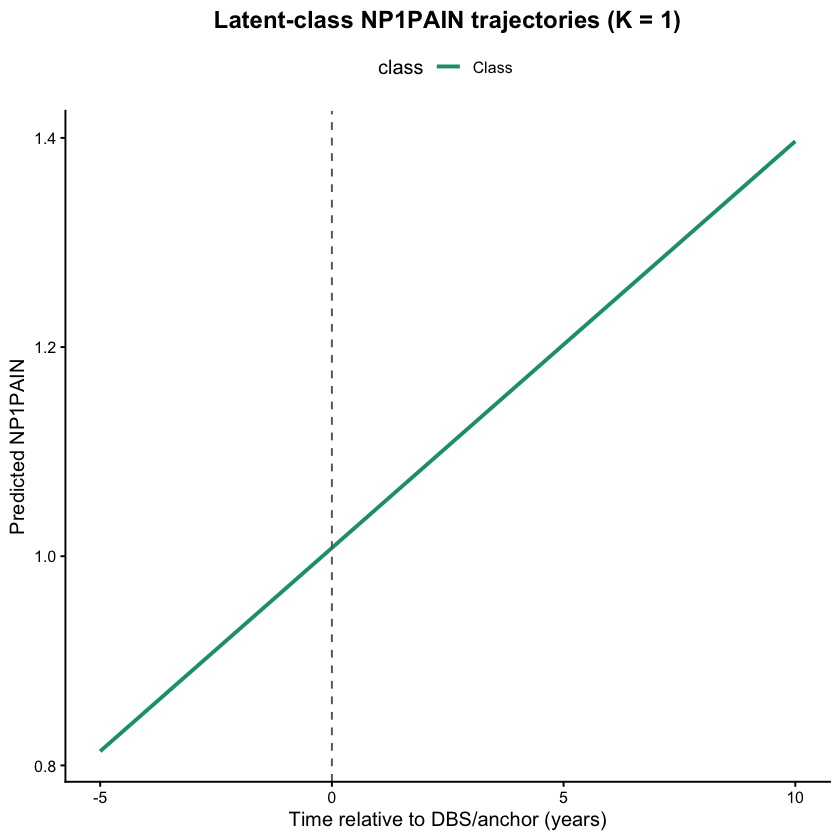

In [6]:
pred_grid <- data.frame(time_years = seq(-5, 10, length.out = 200))
pred <- lcmm::predictY(best, pred_grid, var.time = "time_years")
pred_df <- as.data.frame(pred$pred) %>% dplyr::mutate(time_years = pred_grid$time_years)

class_cols <- grep("^Ypred", names(pred_df), value = TRUE)
pred_long <- pred_df %>% tidyr::pivot_longer(all_of(class_cols),
                                             names_to = "class", values_to = "y") %>%
  dplyr::mutate(class = gsub("Ypred_class|Ypred", "Class ", class))

p_cls <- ggplot(pred_long, aes(x = time_years, y = y, colour = class)) +
  geom_line(linewidth = 1.1) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40") +
  labs(title = sprintf("Latent-class NP1PAIN trajectories (K = %s)", best_k),
       x = "Time relative to DBS/anchor (years)", y = "Predicted NP1PAIN") +
  scale_colour_brewer(palette = "Dark2") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "top")
p_cls
save_fig(p_cls, "Fig09_latent_class_traj", width = 7, height = 4.6)

In [7]:
save_object(cls_arm, "lcmm_class_membership")
save_object(best, "lcmm_best_model")
cat("Saved lcmm_class_membership.rds and lcmm_best_model.rds\n")

Saved lcmm_class_membership.rds and lcmm_best_model.rds
